# Landslide Probability Modeling Notebook

This notebook demonstrates the full workflow for computing
probabilistic landslide failure P(F) under four scenarios:

1. **AR (post-earthquake) — March 2023 event**: real-time IMERG recharge + legacy
   cohesion reduction from the earthquake. Uses `landslide_probability_slope_dist.py`.
2. **AR (post-earthquake) — historical climate composite**: maximum recharge
   across multiple historical AR events + legacy cohesion reduction. Enables
   proactive hazard mapping using the same landslide component without reliance on real-time data.
3. **Coseismic (dry)**: Newmark sliding-block FS threshold, near-zero recharge.
   Uses `landslide_probability_newmark_sliding_block.py`.
4. **AR before earthquake (pre-seismic AR)**: Newmark sliding-block FS threshold
   driven by the March 2023 AR recharge field, representing full soil saturation
   at the time of the earthquake.

The two custom components both extend the original `landslide_probability.py`
(Strauch et al., 2018). Key differences are summarised below.

| Feature | `landslide_probability.py` (original) | `landslide_probability_slope_dist.py` (AR) | `landslide_probability_newmark_sliding_block.py` (coseismic) |
|---|---|---|---|
| Slope input | Single `topographic__slope` | Triangular dist. from `slope_min/mean/max` | Triangular dist. from `slope_min/mean/max` |
| FS failure threshold | FS ≤ 1.0 | FS ≤ 1.0 | FS ≤ `(PGA / sin(arctan(θ))) + 1` |
| Additional required field | — | Three slope fields | `peak__ground_acceleration` + Three slope fields |
| Slope mask on core nodes | slope > 0 | `slope_mean` ≥ 15° | `slope_mean` ≥ 15° |

### Reference
Jimenez, H. N., Istanbulluoglu, E., Gorum, T., Stanley, T. A., Amatya, P. M., Tanyas, H., Demirel, M. C., Akgun, A., and Bozkurt, D.: Modeling the combined effects of the 2023 Türkiye-Syria Earthquake and an Atmospheric River event on landslide hazard, EGUsphere [preprint], https://doi.org/10.5194/egusphere-2025-3011, 2025.

Strauch, R., Istanbulluoglu, E., Nudurupati, S., Bandaragoda, C., Gasparini, N., Tucker, G.
(2018). A hydroclimatological approach to predicting regional landslide probability using
Landlab. *Earth Surface Dynamics*, 6(1), 49–75. https://doi.org/10.5194/esurf-6-49-2018

Nudurupati, S. S., Istanbulluoglu, E., Tucker, G. E., Gasparini, N. M., Hobley, D. E. J., Hutton, E. W. H., et al. (2023). On transient semi-arid ecosystem dynamics using Landlab: Vegetation shifts, topographic refugia, and response to climate. Water Resources Research, 59, e2021WR031179. https://doi.org/10.1029/2021WR031179

---
## To run this notebook
Click in each cell and press **Shift + Enter**, or use **Cell → Run All** from the menu.
All required input files must be present in the paths specified in **Section 2**.


## 1. Import Libraries

Standard Python libraries plus Landlab utilities and two custom
`LandslideProbability` components supplied with this repository.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from landlab.io import read_esri_ascii, write_esri_ascii
from landlab.components import FlowAccumulator, SinkFillerBarnes
from landlab import imshow_grid_at_node

# AR / post-earthquake component — stochastic triangular slope distribution
from landslide_probability_slope_dist import LandslideProbability as LandslideProbability_AR

# Coseismic component — Newmark sliding-block FS threshold
from landslide_probability_newmark_sliding_block import LandslideProbability as LandslideProbability_Coseismic

import warnings
warnings.simplefilter("ignore", DeprecationWarning)

st = time.time()


## 2. Input / Output File Paths

All raster inputs are ESRI ASCII grids (.asc). Adjust these paths to match your local directory structure. Recharge data are taken from the output of the `SoilMoisture` model notebook

In [2]:
data_folder     = 'landslide_input/'      # terrain, soil, and lithology inputs
recharge_folder = 'recharge/'   # spatially distributed IMERG recharge grids
output_folder   = 'landslide_output/'     # destination for probability-of-failure outputs

## 3. Build the Landlab Raster Model Grid

The DEM is read using Landlab's `read_esri_ascii`, which returns a `RasterModelGrid`
and the elevation array. No-data cells (−9999) are set to closed boundary nodes.
The lowest-elevation core node is designated the watershed outlet.


In [3]:
(grid, Z) = read_esri_ascii(data_folder + 'landslide_run_dem.asc',
                            name='topographic__elevation')

grid.set_nodata_nodes_to_closed(Z, -9999.)

outlet_id = grid.core_nodes[np.argmin(grid.at_node['topographic__elevation'][grid.core_nodes])]
grid.set_watershed_boundary_condition_outlet_id(outlet_id, Z)

print(f"Outlet node ID       : {outlet_id}")
print(f"Outlet elevation (m) : {grid.at_node['topographic__elevation'][outlet_id]:.2f}")
print(f"Number of core nodes : {grid.number_of_core_nodes}")
print(f"Watershed area (km2) : {grid.number_of_core_nodes * grid.dx * grid.dy / 1e6:.2f}")


Outlet node ID       : 12264
Outlet elevation (m) : 336.00
Number of core nodes : 2960569
Watershed area (km2) : 23980.61


## 4. Compute Specific Contributing Area

Sinks are filled with `SinkFillerBarnes` before running `FlowAccumulator` (D8).
Specific contributing area (SCA) is derived as drainage area / cell width and added
as the field `topographic__specific_contributing_area`.


In [4]:
sfb = SinkFillerBarnes(grid, 'topographic__elevation', method='D8',
                       fill_flat=False, ignore_overfill=False)
sfb.run_one_step()

fa = FlowAccumulator(grid, surface='topographic__elevation',
                     flow_director='FlowDirectorD8')
(da, q) = fa.accumulate_flow()

cell_width = grid.dx
ca = grid.at_node['drainage_area'] / cell_width
_ = grid.add_field('topographic__specific_contributing_area', ca, at='node', clobber=True)

print(f"Max drainage area (km2): {np.max(da[grid.nodes]) / 1e6:.2f}")


Max drainage area (km2): 23980.62


## 5. Soil Thickness

Soil thickness (m) is loaded from a pre-processed raster. Values ≤ 0 are replaced with
a minimum of 0.35 m. An elevation-dependent adjustment is then applied to steep,
high-elevation nodes to reflect shallower soils in alpine terrain.


In [5]:
(_, hs) = read_esri_ascii(data_folder + 'soil__thickness.asc', name='soil__thickness')
grid.set_nodata_nodes_to_closed(hs, -9999.)

# Replace non-positive values with a minimum soil depth
for i in range(len(hs)):
    if hs[i] <= 0:
        hs[i] = 0.35

# Elevation-dependent thinning on steep slopes (slope > 0.28 m/m, elevation > 1500 m)
# Slope fields must be loaded before running this block (see Section 6).
hs_min = 0.3   # m
hs_max = 2.0   # m
Zmax = np.max(Z[grid.core_nodes])

_ = grid.add_field('soil__thickness', hs, at='node', clobber=True)


## 6. Slope Fields

Three slope rasters (min, mean, max) are loaded. Source rasters store values as integers
multiplied by 1×10⁷; dividing by 1×10⁷ recovers slope in m/m.

- `topographic__slope_min`, `topographic__slope_mean`, `topographic__slope_max` are all
  required by the AR component (`landslide_probability_slope_dist.py`).
- The coseismic component (`landslide_probability_newmark_sliding_block.py`) requires
  only `topographic__slope`, aliased here from the mean slope for consistency.


In [6]:
(_, Smin)  = read_esri_ascii(data_folder + 'slope_min_90m.asc',  name='topographic__slope_min')
(_, Smean) = read_esri_ascii(data_folder + 'slope_mean_90m.asc', name='topographic__slope_mean')
(_, Smax)  = read_esri_ascii(data_folder + 'slope_max_90m.asc',  name='topographic__slope_max')

_ = grid.add_field('topographic__slope_min',  Smin  * 1e-7, at='node', clobber=True)
_ = grid.add_field('topographic__slope_mean', Smean * 1e-7, at='node', clobber=True)
_ = grid.add_field('topographic__slope_max',  Smax  * 1e-7, at='node', clobber=True)

# Apply elevation-dependent soil thickness adjustment (requires slope; see Section 5)
for i in range(len(hs)):
    if grid.at_node['topographic__slope_mean'][i] > 0.28:
        hs[i] = min(hs_max - ((Z[i] - 1500) / (Zmax - 1500)) * (hs_max - hs_min), 2)
_ = grid.add_field('soil__thickness', hs, at='node', clobber=True)

slope_deg = np.degrees(np.arctan(grid.at_node['topographic__slope_mean']))
print(f"Nodes with slope >= 15 degrees: {np.count_nonzero(slope_deg >= 15)}")


Nodes with slope >= 15 degrees: 747637


## 7. Soil and Rock Properties

### 7a. Lithology-based rock cohesion and friction angle

Lithology classes (1–5: Sedimentary, Metamorphic, Volcanic, Plutonic, Ophiolitic) are
loaded from a raster. Rock cohesion (kPa) and internal friction angle (degrees) are
assigned per class using published values.


In [7]:
(_, lithology) = read_esri_ascii(data_folder + 'MTA_Lithology.asc', name='lithology__class')
grid.add_field('lithology__class', lithology, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(lithology, 0)

# Rock cohesion (kPa) and friction angle (degrees) by lithology class
# Classes: 1=Sedimentary, 2=Metamorphic, 3=Volcanic, 4=Plutonic, 5=Ophiolitic
rock_cohesion_map  = {1: 14.4, 2: 38.0, 3: 40.0, 4: 40.0, 5: 30.0}
friction_angle_map = {1: 28.0, 2: 30.0, 3: 44.0, 4: 44.0, 5: 42.0}

grid.add_zeros('rock_cohesion', at='node', clobber=True)
grid.add_zeros('soil__internal_friction_angle', at='node', clobber=True)

grid.at_node['rock_cohesion'] = np.select(
    [lithology == k for k in rock_cohesion_map],
    list(rock_cohesion_map.values()), default=np.nan)

grid.at_node['soil__internal_friction_angle'] = np.select(
    [lithology == k for k in friction_angle_map],
    list(friction_angle_map.values()), default=np.nan)

RC = grid.at_node['rock_cohesion']


### 7b. Combined root + rock cohesion (min, mode, max)

Root cohesion rasters (kPa) are combined with lithology-derived rock cohesion.
Scaling factors of 0.7 / 1.0 / 1.3 are applied to rock cohesion for min / mode / max,
reflecting uncertainty in rock-mass contribution. Values are converted to Pa for the component.


In [8]:
# Maximum cohesion
(_, Cmax)  = read_esri_ascii(data_folder + 'C_max.asc',  name='soil__maximum_total_cohesion')
Cmax_combined = Cmax + (RC * 1.3)
_ = grid.add_field('soil__maximum_total_cohesion', Cmax_combined * 1000, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Cmax_combined * 1000, -9999)

# Minimum cohesion
(_, Cmin)  = read_esri_ascii(data_folder + 'C_min.asc',  name='soil__minimum_total_cohesion')
Cmin_combined = Cmin + (RC * 0.7)
_ = grid.add_field('soil__minimum_total_cohesion', Cmin_combined * 1000, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Cmin_combined * 1000, -9999)

# Mode cohesion
(_, Cmode) = read_esri_ascii(data_folder + 'C_mode.asc', name='soil__mode_total_cohesion')
Cmode_combined = Cmode + RC
_ = grid.add_field('soil__mode_total_cohesion', Cmode_combined * 1000, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Cmode_combined * 1000, -9999)

# Constant soil density
_ = grid.add_field('soil__density', 2000.0 * np.ones(grid.number_of_nodes), at='node', clobber=True)


## 8. Saturated Hydraulic Conductivity and Transmissivity

Ksat (cm/day) from a topsoil database is scaled by a lateral anisotropy ratio of 10
and converted to m/day. Transmissivity T = Ksat_lateral × hs (m²/day).


In [9]:
(_, Ks) = read_esri_ascii(data_folder + 'Ksat_topsoil.asc',
                          name='saturated_hydraulic__conductivity')

a_lateral = 10  # lateral-to-vertical anisotropy ratio
for i in range(len(Ks)):
    if Ks[i] <= 0.5:
        Ks[i] = 0.5
Ks_lateral = (a_lateral * Ks * 0.0001) / 100  # cm/day -> m/day with anisotropy

_ = grid.add_field('soil__saturated_hydraulic_conductivity', Ks_lateral, at='node', clobber=True)

# Transmissivity = Ksat_lateral * soil thickness; enforced minimum of 0.1 m2/day
To = Ks_lateral * hs
for i in range(len(To)):
    if To[i] < 0.1:
        To[i] = 0.1
_ = grid.add_field('soil__transmissivity', To, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(To, -9999.)


## 9. Peak Ground Acceleration (PGA)

PGA (as a fraction of g) is required by both workflows:

- **AR component**: used to compute a legacy cohesion-reduction coefficient
  (`Legacy_Coefficient`) that scales pre-seismic cohesion to reflect earthquake-induced
  damage. 
- **Coseismic component**: passed directly to the component as
  `peak__ground_acceleration`, from which the Newmark FS threshold is computed
  internally at each node as: `FS_threshold = (PGA / sin(arctan(slope))) + 1`.


In [10]:
(_, pga) = read_esri_ascii(data_folder + 'pga_new_potential.asc', name='peak__ground_acceleration')
for i in range(len(pga)):
    if pga[i] < 0:
        pga[i] = -9999.
# PGA field for the coseismic component
_ = grid.add_field('peak__ground_acceleration', pga, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(pga, -9999.)

# Legacy cohesion coefficient (AR workflow)
# Scales cohesion by (1 - (0.5 + 0.25*PGA)); undamaged where PGA < 0.1g
Coeff_legacy = 1.0 - (0.5 + 0.25 * pga)
for i in range(len(pga)):
    if pga[i] < 0.1:
        Coeff_legacy[i] = 1.0
_ = grid.add_field('legacy__coefficient', Coeff_legacy, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Coeff_legacy, -9999.)


## 10. Groundwater Recharge

IMERG-derived recharge grids (mm/day), routed through the model domain, define the
spatial recharge distributions used across the four scenarios.

**Scenario 1a & 1b — March 2023 AR event**: real-time recharge for the specific storm that
preceded the earthquake. Used in the post-earthquake AR workflow.

**Scenario 2 — Historical climate composite**: the cell-wise maximum of four historical
high-recharge events (December 2001, November 2004, February 2011, December 2018) is used
to construct a worst-case recharge envelope. This composite drives a proactive hazard
mapping approach: it does not rely on real-time event data and instead asks *"what is
the landslide hazard if a historically severe AR follows this earthquake?"*

**Scenario 3 — Dry (coseismic)**: near-zero recharge (0.0001 mm/day) isolates seismic
loading as the sole failure driver.

**Scenario 4 — Pre-seismic AR (AR before earthquake)**: the March 2023 AR recharge
field is passed to the coseismic component. This represents fully saturated soils at
the time of shaking — i.e., the earthquake occurs during or immediately after the AR.

A 30% coefficient of variation is assumed for the lognormal spatial standard deviation
in all scenarios.


In [11]:
# ── Scenario 1 & 2: AR recharge fields ──────────────────────────────────────

# Scenario 1 — March 2023 AR event (real-time)
(_, Recharge_AR) = read_esri_ascii(
    recharge_folder + 'IMERG_Recharge_March_2023_routed.asc', name='Recharge')
for i in range(len(Recharge_AR)):
    if Recharge_AR[i] <= 0:
        Recharge_AR[i] = 0.0001

# Scenario 2 — Historical climate composite
# Four historical high-recharge events are composited by taking the cell-wise
# maximum to create a worst-case historical envelope. This composite drives the
# proactive (climate-record-based) hazard mapping workflow.
(_, Recharge_hist1) = read_esri_ascii(
    recharge_folder + 'IMERG_Recharge_December_2001_routed.asc', name='Recharge')
(_, Recharge_hist2) = read_esri_ascii(
    recharge_folder + 'IMERG_Recharge_November_2004_routed.asc', name='Recharge')
(_, Recharge_hist3) = read_esri_ascii(
    recharge_folder + 'IMERG_Recharge_February_2011_routed.asc', name='Recharge')
(_, Recharge_hist4) = read_esri_ascii(
    recharge_folder + 'IMERG_Recharge_December_2018_routed.asc', name='Recharge')

Recharge_historical = np.maximum.reduce([ Recharge_hist1, Recharge_hist2,
                                          Recharge_hist3, Recharge_hist4])
for i in range(len(Recharge_historical)):
    if Recharge_historical[i] <= 0:
        Recharge_historical[i] = 0.0001


## 11. Workflow A — Post-Earthquake AR, March 2023 Event, Legacy Effects Excluded (Scenario 1a)

**Component**: `landslide_probability_slope_dist.py`

**Key differences from the original Landlab `LandslideProbability` component:**

- **Stochastic slope**: slope is sampled each Monte Carlo iteration from a
  triangular distribution using node-specific `slope_min`, `slope_mean`, and
  `slope_max` fields, rather than a single fixed value. This captures sub-grid
  slope variability at the 90 m DEM resolution used here.
- **Slope mask**: only nodes with slope > 15° are evaluated.

**Recharge**: March 2023 IMERG event recharge (real-time).

Landslide Probability maps can be exported using Landlab's `write_esri_ascii` ran at the end of these workflows using the following format: `write_esri_ascii('your_desired_filename.asc', grid, 'landslide__probability_of_failure')`

In [12]:
# Set March 2023 AR recharge fields
_ = grid.add_field('groundwater__recharge_mean', Recharge_AR, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Recharge_AR, -9999.)
_ = grid.add_field('groundwater__recharge_standard_deviation',
                   Recharge_AR * 0.3, at='node', clobber=True)

number_of_iterations = 2000

LS_prob_AR = LandslideProbability_AR(
    grid,
    number_of_iterations=number_of_iterations,
    groundwater__recharge_distribution='lognormal_spatial',
    groundwater__recharge_mean=grid.at_node['groundwater__recharge_mean'],
    groundwater__recharge_standard_deviation=grid.at_node['groundwater__recharge_standard_deviation']
)

LS_prob_AR.calculate_landslide_probability()


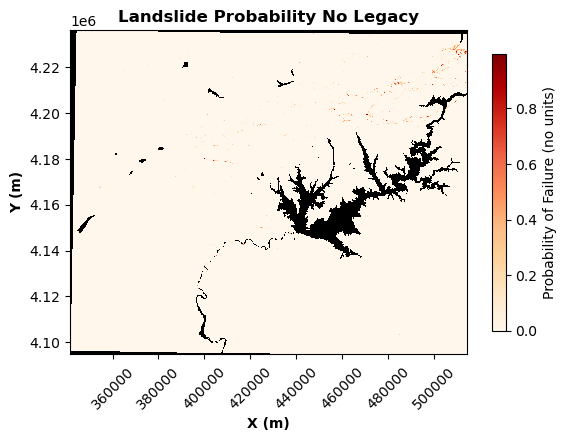

In [13]:
imshow_grid_at_node(grid, 'landslide__probability_of_failure', cmap='OrRd',
                 grid_units=('coordinates', 'coordinates'), shrink=0.75,
                 var_name='Probability of Failure', var_units='no units')
plt.title('Landslide Probability No Legacy', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


## 12. Workflow B — Post-Earthquake AR, March 2023 Event, Legacy Effects Included (Scenario 1b)

**Component**: `landslide_probability_slope_dist.py`

**Key differences from the original Landlab `LandslideProbability` component:**

- **Stochastic slope**: slope is sampled each Monte Carlo iteration from a
  triangular distribution using node-specific `slope_min`, `slope_mean`, and
  `slope_max` fields, rather than a single fixed value. This captures sub-grid
  slope variability at the 90 m DEM resolution used here.
- **Slope mask**: only nodes with slope > 15° are evaluated.
- **Legacy Cohesion**: standard FS ≤ 1.0. Seismic legacy effects are incorporated
  through the `Legacy_Coefficient`.

**Recharge**: March 2023 IMERG event recharge (real-time).

Landslide Probability maps can be exported using Landlab's `write_esri_ascii` ran at the end of these workflows using the following format: `write_esri_ascii('your_desired_filename.asc', grid, 'landslide__probability_of_failure')`

In [14]:
# Adjust Cohesion to incorporate legacy effects
grid.at_node['soil__mode_total_cohesion'] = grid.at_node['soil__mode_total_cohesion']* grid.at_node['legacy__coefficient']
grid.at_node['soil__maximum_total_cohesion'] = grid.at_node['soil__maximum_total_cohesion']* grid.at_node['legacy__coefficient']
grid.at_node['soil__minimum_total_cohesion'] = grid.at_node['soil__minimum_total_cohesion']* grid.at_node['legacy__coefficient']


In [15]:
# Set March 2023 AR recharge fields
_ = grid.add_field('groundwater__recharge_mean', Recharge_AR, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Recharge_AR, -9999.)
_ = grid.add_field('groundwater__recharge_standard_deviation',
                   Recharge_AR * 0.3, at='node', clobber=True)

number_of_iterations = 2000

LS_prob_AR = LandslideProbability_AR(
    grid,
    number_of_iterations=number_of_iterations,
    groundwater__recharge_distribution='lognormal_spatial',
    groundwater__recharge_mean=grid.at_node['groundwater__recharge_mean'],
    groundwater__recharge_standard_deviation=grid.at_node['groundwater__recharge_standard_deviation']
)

LS_prob_AR.calculate_landslide_probability()


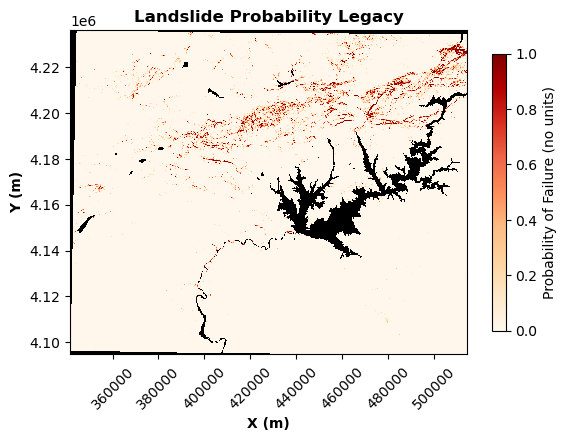

In [16]:
imshow_grid_at_node(grid, 'landslide__probability_of_failure', cmap='OrRd',
                 grid_units=('coordinates', 'coordinates'), shrink=0.75,
                 var_name='Probability of Failure', var_units='no units')
plt.title('Landslide Probability Legacy', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


## 13. Workflow C — Post-Earthquake AR, Historical Climate Composite (Scenario 2)

**Component**: `landslide_probability_slope_dist.py`

**Motivation**: Rather than conditioning the hazard forecast on a specific real-time
storm, this workflow uses a composite of historically severe AR recharge events to
ask: *"What is the post-seismic landslide hazard if a storm drawn from the historical
climate record follows this earthquake?"* This supports proactive hazard mapping that
is not contingent on real-time IMERG data and can be prepared in advance.

**Recharge**: cell-wise maximum across December 2001, November 2004, February 2011, and December 2018 IMERG events (see Section 10). This maximum-envelope approach
approximates the worst-case annual recharge conditions the landscape is likely to
experience.

**Cohesion**: identical legacy-adjusted cohesion fields as Scenario 1b - the same
earthquake damage state is assumed.

Landslide Probability maps can be exported using Landlab's `write_esri_ascii` ran at the end of these workflows using the following format: `write_esri_ascii('your_desired_filename.asc', grid, 'landslide__probability_of_failure')`

In [17]:
# Set historical composite recharge fields
_ = grid.add_field('groundwater__recharge_mean', Recharge_historical, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Recharge_historical, -9999.)
_ = grid.add_field('groundwater__recharge_standard_deviation',
                   Recharge_historical * 0.3, at='node', clobber=True)

number_of_iterations = 2000

LS_prob_AR_hist = LandslideProbability_AR(
    grid,
    number_of_iterations=number_of_iterations,
    groundwater__recharge_distribution='lognormal_spatial',
    groundwater__recharge_mean=grid.at_node['groundwater__recharge_mean'],
    groundwater__recharge_standard_deviation=grid.at_node['groundwater__recharge_standard_deviation']
)

LS_prob_AR_hist.calculate_landslide_probability()


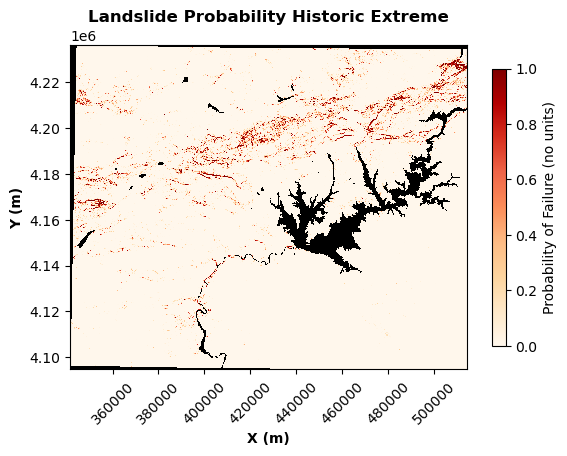

In [18]:
imshow_grid_at_node(grid, 'landslide__probability_of_failure', cmap='OrRd',
                 grid_units=('coordinates', 'coordinates'), shrink=0.75,
                 var_name='Probability of Failure', var_units='no units')
plt.title('Landslide Probability Historic Extreme', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


## 14. Workflow D - Coseismic, Dry Conditions (Scenario 3)

**Component**: `landslide_probability_newmark_sliding_block.py`

**Key differences from the original Landlab `LandslideProbability` component:**

- **Stochastic slope**: slope is sampled each Monte Carlo iteration from a
  triangular distribution using node-specific `slope_min`, `slope_mean`, and
  `slope_max` fields, rather than a single fixed value. This captures sub-grid
  slope variability at the 90 m DEM resolution used here.
- **Slope mask**: nodes with slope < 15° are excluded.
- **Modified FS failure threshold (Newmark criterion)**: failure is counted when
  `FS <= (PGA / sin(arctan(slope))) + 1` rather than `FS <= 1.0`. This is the
  Newmark (1965) critical-acceleration ratio — the PGA at which permanent downslope
  displacement initiates — computed per node from local slope and `peak__ground_acceleration`.
- **Additional required input field**: `peak__ground_acceleration` (fraction of g).

**Recharge**: near-zero (0.0001 mm/day) — seismic loading is the sole failure driver,
representing a dry-season or pre-storm earthquake.

**Output**: `coseismic_dry_landslide_probability.asc`

Landslide Probability maps can be exported using Landlab's `write_esri_ascii` ran at the end of these workflows using the following format: `write_esri_ascii('your_desired_filename.asc', grid, 'landslide__probability_of_failure')`

In [19]:
# Adjust Cohesion to remove legacy effects, which are only applied for POST-EARTHQUAKE reduction in shear strength
grid.at_node['soil__mode_total_cohesion'] = grid.at_node['soil__mode_total_cohesion']/ grid.at_node['legacy__coefficient']
grid.at_node['soil__maximum_total_cohesion'] = grid.at_node['soil__maximum_total_cohesion']/ grid.at_node['legacy__coefficient']
grid.at_node['soil__minimum_total_cohesion'] = grid.at_node['soil__minimum_total_cohesion']/ grid.at_node['legacy__coefficient']


In [20]:
# Set near-zero (dry) recharge for coseismic scenario
recharge_dry = np.full(grid.number_of_nodes, 0.0001)
_ = grid.add_field('groundwater__recharge_mean', recharge_dry, at='node', clobber=True)
_ = grid.add_field('groundwater__recharge_standard_deviation',
                   recharge_dry * 0.3, at='node', clobber=True)


In [21]:
number_of_iterations = 2000

LS_prob_Coseismic_dry = LandslideProbability_Coseismic(
    grid,
    number_of_iterations=number_of_iterations,
    groundwater__recharge_distribution='lognormal_spatial',
    groundwater__recharge_mean=grid.at_node['groundwater__recharge_mean'],
    groundwater__recharge_standard_deviation=grid.at_node['groundwater__recharge_standard_deviation']
)

LS_prob_Coseismic_dry.calculate_landslide_probability()


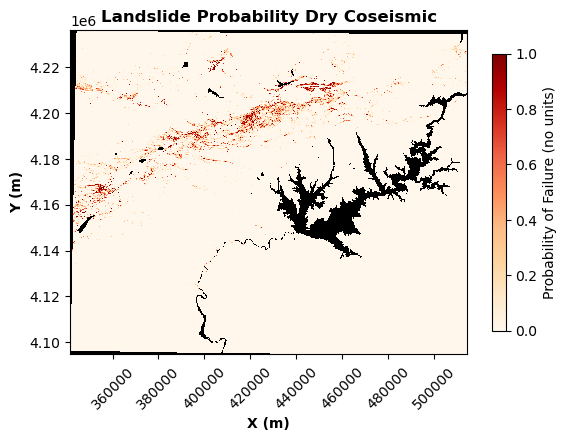

In [22]:
imshow_grid_at_node(grid, 'landslide__probability_of_failure', cmap='OrRd',
                 grid_units=('coordinates', 'coordinates'), shrink=0.75,
                 var_name='Probability of Failure', var_units='no units')
plt.title('Landslide Probability Dry Coseismic', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


## 15. Workflow E — AR Before Earthquake, March 2023 Recharge (Scenario 4)

**Component**: `landslide_probability_newmark_sliding_block.py` (same as Scenario 3)

**Motivation**: This scenario represents the case where the atmospheric-river event
occurs *before* the earthquake — i.e., soils are already fully saturated at the time of
shaking. The March 2023 AR recharge field is passed to the coseismic component so that
the Newmark FS calculation reflects elevated pore-water pressures at the moment of the
seismic event.

Comparing Scenario 4 with Scenario 3 (dry coseismic) isolates the contribution of
antecedent soil moisture to seismically triggered failure probability, and comparing
with Scenario 1b (post-EQ AR) reveals whether the sequencing of shaking and rainfall
meaningfully changes the spatial pattern of hazard.

**Key setup differences from Scenario 3:**
- Recharge field is replaced with the March 2023 AR event recharge.
- All other inputs (PGA, cohesion, slope) are identical to Scenario 3.
- No legacy cohesion reduction is applied — the earthquake has not yet occurred.

Landslide Probability maps can be exported using Landlab's `write_esri_ascii` ran at the end of these workflows using the following format: `write_esri_ascii('your_desired_filename.asc', grid, 'landslide__probability_of_failure')`


In [23]:
# Set March 2023 AR recharge for the pre-seismic AR scenario
# The Newmark FS threshold is still applied — the earthquake is the trigger -
# but the relative wetness at each node reflects the saturated post-AR soil state.
_ = grid.add_field('groundwater__recharge_mean', Recharge_AR, at='node', clobber=True)
grid.set_nodata_nodes_to_closed(Recharge_AR, -9999.)
_ = grid.add_field('groundwater__recharge_standard_deviation',
                   Recharge_AR * 0.3, at='node', clobber=True)

number_of_iterations = 2000

LS_prob_AR_before_EQ = LandslideProbability_Coseismic(
    grid,
    number_of_iterations=number_of_iterations,
    groundwater__recharge_distribution='lognormal_spatial',
    groundwater__recharge_mean=grid.at_node['groundwater__recharge_mean'],
    groundwater__recharge_standard_deviation=grid.at_node['groundwater__recharge_standard_deviation']
)

LS_prob_AR_before_EQ.calculate_landslide_probability()


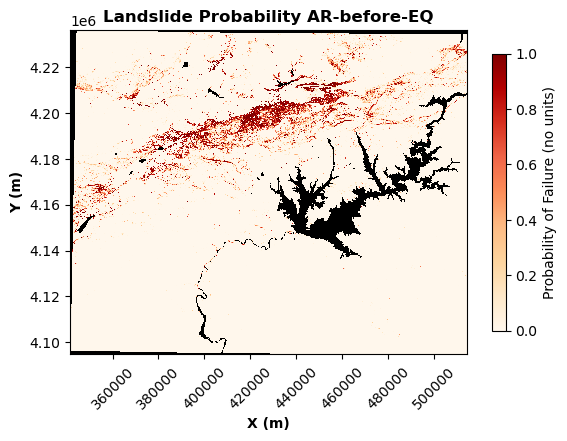

In [24]:
imshow_grid_at_node(grid, 'landslide__probability_of_failure', cmap='OrRd',
                 grid_units=('coordinates', 'coordinates'), shrink=0.75,
                 var_name='Probability of Failure', var_units='no units')
plt.title('Landslide Probability AR-before-EQ', fontweight='bold')
plt.xlabel('X (m)', fontweight='bold')
plt.ylabel('Y (m)', fontweight='bold')
plt.xticks(rotation=45)
plt.show()


## 16. Run Time

In [25]:
elapsed = time.time() - st
print(f"Total elapsed time: {elapsed:.1f} s  ({elapsed / 60:.1f} min)")


Total elapsed time: 1467.7 s  (24.5 min)
